# Gene set enrichment analysis
Notebook is based on this tutorial: https://gseapy.readthedocs.io/en/latest/gseapy_example.html

For the GSEA analysis DEG identified in 'scanpy-subclustering' is used. These are saved in a pickle-file. 

In [1]:
import scanpy as sc
import anndata as ad

import utils

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gseapy as gp


import os
import re
import glob
import datetime

import pickle 

current_time = f"{datetime.datetime.now():%Y-%m-%d %H:%M}"

/home/frederik/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Processing

Read in all subclusters into a dictionary

In [2]:
subcluster_paths = glob.glob('../../h5ad/subcluster*')
subcluster_names = [subcluster_path.replace('../../h5ad/subcluster_', '').replace('.h5ad', '') for subcluster_path in subcluster_paths]

subcluster_adata = {}
for i, subcluster_path in enumerate(subcluster_paths):
    subcluster_adata[subcluster_names[i]] = sc.read_h5ad(subcluster_path)

Read DEG from all subclusters into a dictionary

In [10]:
DE_df = {}
gene_list = {}
cutoff = {'lfc': .2, 'pct_expression': .2, 'pval_adj': .1}
for DE_path in glob.glob('../../DE/*'):
    subcluster_name = os.path.basename(DE_path).replace('.txt', '') # e.g. Acinar_0
    DE_subcluster = pd.read_csv(DE_path, sep = '\t')
    DE_df[subcluster_name] = DE_subcluster
    gene_list[subcluster_name] = DE_subcluster[(DE_subcluster['pval_adj'] < cutoff['pval_adj']) &
                (DE_subcluster['pct_expression'] > cutoff['pct_expression'])  &
                (DE_subcluster['logfoldchange'] > cutoff['lfc'])]['gene']

Run the GSEA-analysis

In [11]:
enrichr_results = {}
for subcluster, list_of_genes in gene_list.items():  
    subcluster_adata_name = re.sub('_[0-9]', '', subcluster)
    print(subcluster)
    enr = gp.enrichr(gene_list=list_of_genes, 
                    gene_sets=['KEGG_2021_Human', 'Reactome_2022', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023', 'GO_Biological_Process_2023'], 
                    organism='human',
                    background=subcluster_adata[subcluster_adata_name].var_names,
                    outdir=None,
                    )
    # move Term ID to separate column
    Term_ID = enr.results['Term'].str.extract(r'R-HSA-.*|(GO:.*)').replace(r'\)', '', regex=True)
    
    # remove Term ID from Term column (but keep original in case of bad substitution in regex)
    enr.results['Term_original'] = enr.results['Term'].copy()
    enr.results['Term'] = enr.results['Term'].str.replace('R-HSA-.*|(\\(GO:.*)', '', regex=True)

    enr.results.insert(2, 'Term_ID', Term_ID)
    enrichr_results[subcluster] = enr.results

Acinar_0
Acinar_1
Acinar_2
Acinar_3
Acinar_4
Acinar_5
Ductal_0
Ductal_1
Ductal_2
Ductal_3
Endocrine_0
Endocrine_1
Endocrine_2
Endocrine_3
Endocrine_4
Endocrine_5
Endocrine_6
Endocrine_7
Endothelial_0
Endothelial_1
Endothelial_2
Endothelial_3
Endothelial_4
Endothelial_5
Immune_0
Immune_1
Immune_2
Immune_3
Immune_4
Immune_5
Immune_6
Immune_7
Stellate_0
Stellate_1
Stellate_2
Stellate_3


Save dictionary to file with pickle. <br> Can be opened as described here: https://stackoverflow.com/questions/19201290/how-to-save-a-dictionary-to-a-file/19201448#19201448

In [ ]:
#with open('../../enrich_results_subclusters.pkl', 'wb') as f:
#    pickle.dump(enrichr_results, f)

## Analysis
1. Some code for making venn-diagrams. It is unfortunately not functional at the moment
2. Visualization of enriched terms in a barchart. 
3. saving results to csv file

In [3]:
with open('../../pkl/enrich_results_subclusters.pkl', 'rb') as f:
    enrichr_results = pickle.load(f)

In [13]:
enrichr_results_filtered = {}
for subcluster_name, df in enrichr_results.items():
    df['gene_count'] = df['Genes'].apply(lambda x: (x.count(';') + 1))
    df = df[(df['gene_count'] > 6) & 
                            (df['Adjusted P-value'] < 5e-02) &
                            (df['Gene_set'] == 'Reactome_2022')].drop_duplicates('Genes')
    enrichr_results_filtered[subcluster_name] = df

In [6]:
all_elements = []
for name, df in enrichr_results_filtered.items():
    if(name == 'Acinar_0' or name == 'Acinar_1' or name == 'Acinar_2' or name == 'Acinar_3' or name == 'Acinar_4' or name == 'Acinar_5'):
        all_elements.extend(df['Term'].tolist())

In [7]:
from collections import Counter
element_counts = Counter(all_elements)
element_counts

Counter({'Metabolism ': 5,
         'Signal Transduction ': 5,
         'Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers ': 5,
         'Membrane Trafficking ': 5,
         'Disease ': 5,
         'Transport Of Small Molecules ': 5,
         'RHO GTPase Cycle ': 5,
         'Vesicle-mediated Transport ': 4,
         'Intracellular Signaling By Second Messengers ': 4,
         'Gene Expression (Transcription) ': 4,
         'Post-translational Protein Modification ': 4,
         'MAPK Family Signaling Cascades ': 4,
         'Signaling By Rho GTPases ': 4,
         'Cell Cycle ': 4,
         'Immune System ': 4,
         'Cell Cycle, Mitotic ': 4,
         'Metabolism Of Proteins ': 4,
         'Cellular Responses To Stress ': 4,
         'RAF/MAP Kinase Cascade ': 4,
         'Signaling By Receptor Tyrosine Kinases ': 4,
         'Developmental Biology ': 4,
         'Class I MHC Mediated Antigen Processing And Presentation ': 4,
         'RHO GTPase Ef

In [8]:
unique_elements = [elem for elem, count in element_counts.items() if count == 1]
overlapping_elements = [elem for elem, count in element_counts.items() if count > 1]

In [21]:
Terms_Duct_0 = np.unique(enrichr_results['Ductal_0']['Term']).tolist()
Terms_Duct_1 = np.unique(enrichr_results['Ductal_1']['Term']).tolist()
Terms_Duct_2 = np.unique(enrichr_results['Ductal_2']['Term']).tolist()

terms_collected = Terms_Duct_0 + Terms_Duct_1 + Terms_Duct_2
terms_count = Counter(terms_collected)

unique_terms = [k for k, v in terms_count.items() if v == 1]
#terms_unique_Duct_0 = [k.isin(unique_terms) for k in terms_count]
terms_collected = []
terms_collected.append([Terms_Duct_0, Terms_Duct_1, Terms_Duct_2])

#terms_all = [Terms_Duct_0, Terms_Duct_1, Terms_Duct_2]
# 814 unique in Ductal_0
# 2951 common
# 2143 unique in Ductal 1

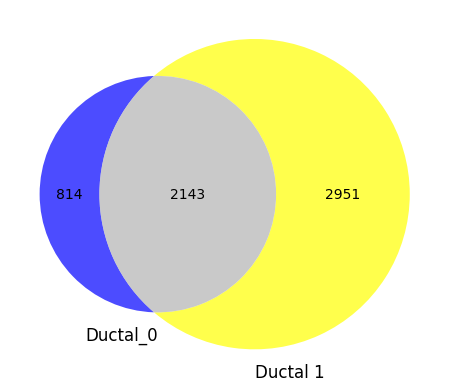

In [38]:
from matplotlib_venn import venn2, venn2_circles 
from matplotlib import pyplot as plt 

venn2(subsets=(814, 2951, 2143),  
    set_labels=('Ductal_0', 'Ductal 1'), 
    set_colors=("blue", "yellow"), alpha=0.7) 

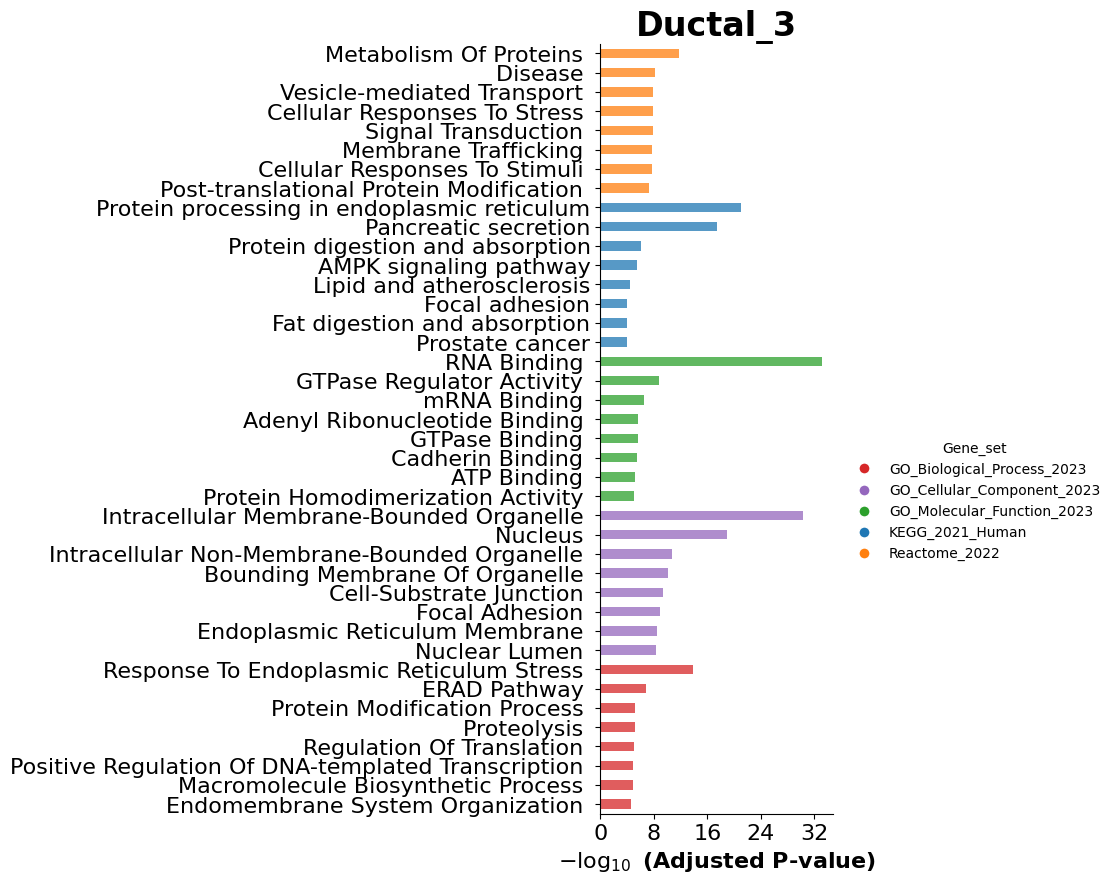

In [22]:
# categorical scatterplot
population = 'Ductal_3'
ax = gp.barplot(enrichr_results[population], 
        column="Adjusted P-value", 
        group='Gene_set',
        top_term=8,
        figsize=(3,10), 
        title=population,
        color = {'KEGG_2021_Human': 'tab:blue',
                'Reactome_2022':'tab:orange',
                'GO_Molecular_Function_2023': 'tab:green',
                'GO_Biological_Process_2023': 'tab:red',
                'GO_Cellular_Component_2023': 'tab:purple'})
#plt.savefig(f'../../plots/enrichr_{population}.png', bbox_inches = 'tight')

In [232]:
columns = ['Gene_set', 'Term', 'P-value', 'Adjusted P-value', 'Odds Ratio',	'Combined Score', 'Genes']
for subcluster_name, enrichr_result_DF in enrichr_results.items():
    enrichr_result_DF[columns].to_csv(f'../../enrichr/{subcluster_name}.txt', sep='\t')